# 🎮 Krafton — Player Churn & Engagement Prediction
## Complete Classification ML Pipeline (Random Forest Classifier)

**Objective:** Predict player churn as a proxy for player engagement and use the model output to support personalized retention actions.

**Business context:** Krafton, like many game developers, faces the challenge of player retention. A significant portion of players may disengage or churn over time. This can reduce revenue, weaken community engagement, and increase the cost of acquiring new players.

**Approach:** Build a Random Forest Classification model using player telemetry data, evaluate its classification performance, identify important player features, and convert engagement probabilities into a simple personalized ranking / discount recommendation.

---
## Step 1 — Data Loading


**What:** Load the raw Krafton player telemetry dataset into the notebook.

**Why:** Every machine-learning pipeline starts with a dataset containing the player information that the model will learn from.

In [1]:
# ============================================================
# STEP 1: DATA Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = '/content/krafton_player_telemetry_raw_500.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully.
Rows: 500
Columns: 10


---
## Step 2 — Data Understanding / Data Inspection

**What:** Inspect the dataset before cleaning or modeling.

**Why:** We need to understand the available columns, data types, sample records, and overall structure before making changes.

The target variable `churned` and the player telemetry features used by the classifier should be present.

In [2]:
# ============================================================
# STEP 2: DATA UNDERSTANDING / DATA INSPECTION
# ============================================================

print("Dataset Info:")
display(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 500 non-null    object 
 1   session_frequency_weekly  500 non-null    int64  
 2   avg_survival_time_min     463 non-null    float64
 3   kd_ratio                  491 non-null    float64
 4   win_loss_streak           500 non-null    int64  
 5   currency_balance_uc       500 non-null    object 
 6   lifetime_value_usd        500 non-null    float64
 7   royale_pass_tier          480 non-null    float64
 8   days_since_last_session   500 non-null    int64  
 9   churned                   500 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 39.2+ KB


None


First 5 rows:


,player_id,session_frequency_weekly,avg_survival_time_min,kd_ratio,win_loss_streak,currency_balance_uc,lifetime_value_usd,royale_pass_tier,days_since_last_session,churned
0,UID_10000,19,13.788937,0.224458,-2,3430,88.787176,90.0,29,0
1,UID_10001,13,14.803923,1.020500,-4,1301,6.410920,46.0,1,1
2,UID_10002,21,NaN,1.504195,-3,2541,2.404152,15.0,24,0
3,UID_10003,30,NaN,1.537584,-3,2051,24.232771,98.0,17,1
4,UID_10004,12,5.111653,1.139948,-2,441 UC,1.871177,44.0,28,1



Column Names:
['player_id', 'session_frequency_weekly', 'avg_survival_time_min', 'kd_ratio', 'win_loss_streak', 'currency_balance_uc', 'lifetime_value_usd', 'royale_pass_tier', 'days_since_last_session', 'churned']


**Interpretation:** Review the displayed column names, data types, and first few records. The next step prepares these fields for classification.

---
## Step 3 — Data Cleaning

**What:** Fix missing values and known data-quality problems in the telemetry data.

**Why:** Machine-learning models work more reliably when the input data is complete, numeric where required, and free from obvious invalid values.

The original classification logic performs the following cleaning actions:

- Missing numeric values → median
- Missing categorical values → mode
- Negative weekly session frequency → clipped to 0
- Extreme `kd_ratio` values → capped at the 99th percentile
- `currency_balance_uc` → cleaned and converted to numeric

In [3]:
# ============================================================
# STEP 3: DATA CLEANING
# ============================================================

# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Clip negative session frequency to 0
df['session_frequency_weekly'] = df['session_frequency_weekly'].clip(lower=0)

# Cap extreme KD-ratio values at the 99th percentile
max_kd = df['kd_ratio'].quantile(0.99)
df['kd_ratio'] = df['kd_ratio'].clip(upper=max_kd)

# Clean currency balance and convert it to numeric
import re
df['currency_balance_uc'] = df['currency_balance_uc'].astype(str).apply(
    lambda x: re.sub(r'[^0-9.]', '', x)
)
df['currency_balance_uc'] = pd.to_numeric(
    df['currency_balance_uc'],
    errors='coerce'
).fillna(0)

# Encode player ID
le = LabelEncoder()
df['player_id_encoded'] = le.fit_transform(df['player_id'].astype(str))

print("Data cleaning completed.")
display(df.describe())

Data cleaning completed.


,session_frequency_weekly,avg_survival_time_min,kd_ratio,win_loss_streak,currency_balance_uc,lifetime_value_usd,royale_pass_tier,days_since_last_session,churned,player_id_encoded
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,16.770000,14.944176,308.349908,-0.612000,2487.240000,106.381826,66.428000,14.29600,0.238000,249.500000
std,12.067325,7.644508,329.910596,2.897282,1483.698467,84.965597,40.340147,8.72701,0.426286,144.481833
min,0.000000,1.000000,0.000000,-5.000000,7.000000,0.051501,1.000000,0.00000,0.000000,0.000000
25%,6.000000,9.501530,1.766660,-3.000000,1157.750000,30.183939,35.000000,7.00000,0.000000,124.750000
50%,17.000000,14.362328,181.214943,-1.000000,2422.500000,86.585887,64.000000,14.00000,0.000000,249.500000
75%,26.000000,20.037559,577.468073,2.000000,3794.250000,177.539123,94.000000,21.00000,0.000000,374.250000
max,42.000000,31.263657,999.620525,4.000000,4987.000000,280.456932,150.000000,29.00000,1.000000,499.000000


**Interpretation:** Missing values are handled, invalid weekly session values are corrected, extreme KD ratios are capped, and the currency field is converted into a numeric form.

---
## Step 4 — Feature Selection

**What:** Select the player-behavior variables used as inputs to the classification model.

**Why:** The Random Forest should learn from business-relevant telemetry variables rather than unrelated fields.

The original project uses eight features covering session activity, gameplay performance, player value, and recency.

In [4]:
# ============================================================
# STEP 4: FEATURE SELECTION
# ============================================================

target = 'churned'

features = [
    'session_frequency_weekly',
    'avg_survival_time_min',
    'kd_ratio',
    'win_loss_streak',
    'currency_balance_uc',
    'lifetime_value_usd',
    'royale_pass_tier',
    'days_since_last_session'
]

X = df[features]
y = df[target]

print("Target variable:", target)
print("\nSelected features:")
print(features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Target variable: churned

Selected features:
['session_frequency_weekly', 'avg_survival_time_min', 'kd_ratio', 'win_loss_streak', 'currency_balance_uc', 'lifetime_value_usd', 'royale_pass_tier', 'days_since_last_session']

Feature matrix shape: (500, 8)
Target shape: (500,)


**Interpretation:** `X` contains the player attributes used by the model, while `y` contains the `churned` outcome that the classifier will learn to predict.

---
## Step 5 — Define Target Variable

**What:** Set `churned` as the target variable.

**Why:** This is a classification problem where the model predicts the player's churn / non-churn class. In the original project, churn is also used as a proxy for engagement and retention.

In [5]:
# ============================================================
# STEP 5: DEFINE TARGET VARIABLE
# ============================================================

print("Target variable:", target)
print("\nTarget distribution:")
display(y.value_counts())

print("\nTarget data type:", y.dtype)

Target variable: churned

Target distribution:


,count
churned,
0,381
1,119



Target data type: int64


---
## Step 6 — Train-Test Split

**What:** Split the dataset into training data and testing data.

**Why:** The model must be evaluated on records it did not see during training.

The original logic uses a **20% test size** and `random_state=42`.

In [6]:
# ============================================================
# STEP 6: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 400
Testing rows: 100


**Interpretation:** The training set is used to learn player churn patterns, while the test set is held back for evaluation on unseen players.

---
## Step 7 — Model Building

**What:** Create the Random Forest Classifier.

**Why:** Random Forest combines multiple decision trees and uses their combined results for classification. It can learn non-linear relationships across the player telemetry features.

The original model uses **100 trees** with `random_state=42`.

In [7]:
# ============================================================
# STEP 7: MODEL BUILDING
# ============================================================

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest Classifier created.")

Random Forest Classifier created.


**Interpretation:** The classifier has now been created. It still needs to learn from the training data.

---
## Step 8 — Model Training

**What:** Train the Random Forest on the training dataset.

**Why:** This is the learning stage where the classifier identifies patterns connecting player telemetry features with the `churned` target.

In [8]:
# ============================================================
# STEP 8: MODEL TRAINING
# ============================================================

clf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Interpretation:** The trained model can now be used to classify unseen test players.

---
## Step 9 — Prediction

**What:** Generate churn predictions for the test dataset.

**Why:** These predictions are compared with the actual test labels to evaluate the model.

In [9]:
# ============================================================
# STEP 9: PREDICTION
# ============================================================

y_pred = clf.predict(X_test)

print("Predictions generated for the test set.")
print("\nFirst predictions:")
print(y_pred[:10])

Predictions generated for the test set.

First predictions:
[0 0 0 0 0 0 0 0 1 0]


---
## Step 10 — Model Evaluation

**What:** Measure classification performance using accuracy and the classification report.

**Why:** A business model needs measurable evidence of how well it classifies unseen players.

The original logic reports accuracy, precision, recall, F1-score, and support.

In [10]:
# ============================================================
# STEP 10: MODEL EVALUATION
# ============================================================

from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89        85
           1       0.00      0.00      0.00        15

    accuracy                           0.80       100
   macro avg       0.42      0.47      0.44       100
weighted avg       0.72      0.80      0.76       100



**Interpretation:** Accuracy gives an overall view of correct predictions, while precision, recall, and F1-score provide class-level detail.

---
## Step 11 — Confusion Matrix

**What:** Visualize correct and incorrect classification results.

**Why:** A confusion matrix shows how many players were correctly or incorrectly classified into the Active and At-Risk categories.

<Figure size 800x600 with 0 Axes>

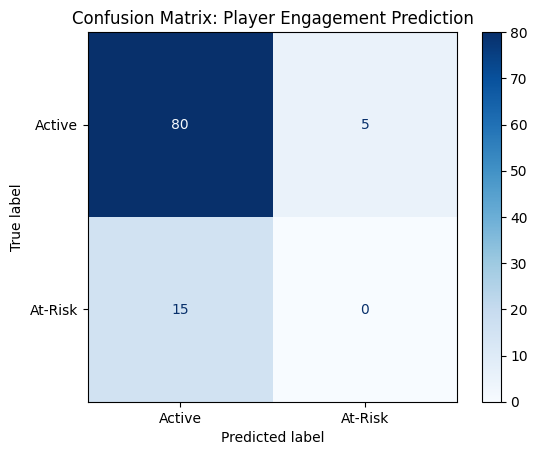

In [11]:
# ============================================================
# STEP 11: CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Active', 'At-Risk']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Player Engagement Prediction')
plt.show()

**Interpretation:** The matrix makes it easier to see where the classifier performs correctly and where it confuses active and at-risk players.

---
## Step 12 — Feature Importance & Model Interpretation

**What:** Identify the player attributes that contribute most to the Random Forest's decisions.

**Why:** Feature importance helps explain the model and shows which player-behavior variables are most influential.

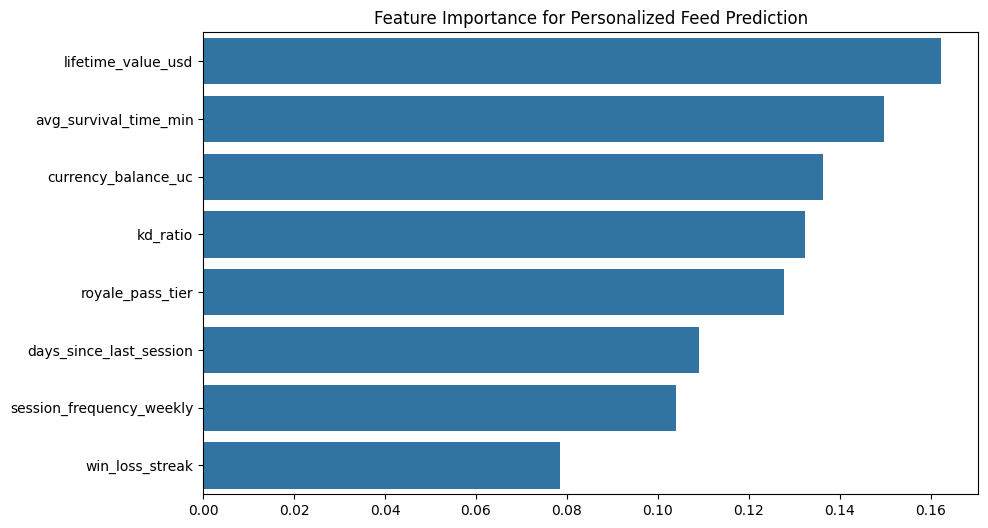

In [12]:
# ============================================================
# STEP 12: FEATURE IMPORTANCE & MODEL INTERPRETATION
# ============================================================

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Personalized Feed Prediction")

sns.barplot(
    x=importances[indices],
    y=[features[i] for i in indices]
)

plt.show()

**Interpretation:** Features with larger importance values contribute more strongly to the Random Forest's prediction decisions.

---
## Step 13 — Personalized Engagement Score

**What:** Convert the model's prediction probability into an engagement score for an individual player.

**Why:** A probability-based score provides more detail than a simple yes/no classification and can be used to rank players for retention actions.

The original logic uses the probability of **class 0 (Active / Not Churning)** as the engagement score.

In [13]:
# ============================================================
# STEP 13: PERSONALIZED ENGAGEMENT SCORE
# ============================================================

def rank_personalized_feed(player_id, model, dataframe, features):
    player_data = dataframe[
        dataframe['player_id'] == player_id
    ][features]

    if player_data.empty:
        return "Player ID not found."

    # Probability of 'Not Churning' (class 0)
    # is used as the engagement score.
    engagement_prob = model.predict_proba(player_data)[0][0]

    return f"Player {player_id} Engagement Score: {engagement_prob:.2f}"


# Example for a specific player
sample_player = df['player_id'].iloc[0]

print(
    rank_personalized_feed(
        sample_player,
        clf,
        df,
        features
    )
)

Player UID_10000 Engagement Score: 0.78


---
## Step 14 — Final Output

**What:** Turn the classification model predictions into a **business-usable output**: a ranked list of players showing their predicted churn status, churn probability, engagement score, and retention action.

**Why:** This is the actual deliverable a retention team can use — not only model metrics, but a practical action list showing which players need attention first.


In [15]:
# ============================================================
# STEP 14: FINAL OUTPUT — BUSINESS-READY RESULTS
# ============================================================

# Build a results table aligned with the test set's original index
results = X_test.copy()

# Add player identity and actual/predicted classification results
results['Player_ID'] = df.loc[X_test.index, 'player_id'].values
results['Actual_Churn'] = y_test.values
results['Predicted_Churn'] = y_pred

# Probability of class 1 = churn probability
results['Churn_Probability'] = clf.predict_proba(X_test)[:, 1].round(3)

# Probability of class 0 = active / not-churning engagement score
results['Engagement_Score'] = clf.predict_proba(X_test)[:, 0].round(3)

# Human-readable business label
results['Risk_Label'] = np.where(
    results['Predicted_Churn'] == 1,
    'Likely to Churn',
    'Not Likely to Churn'
)

# Retention action based on the original engagement-score logic
results['Retention_Action'] = np.where(
    results['Engagement_Score'] < 0.4,
    '50% (Win-back)',
    np.where(
        results['Engagement_Score'] < 0.7,
        '25% (Neutral)',
        '10% (Loyalty)'
    )
)

# Highest churn probability = highest retention priority
results = results.sort_values(
    by='Churn_Probability',
    ascending=False
)

# Reorder columns for a clean, presentable report
results = results[
    [
        'Player_ID',
        'session_frequency_weekly',
        'avg_survival_time_min',
        'kd_ratio',
        'win_loss_streak',
        'currency_balance_uc',
        'lifetime_value_usd',
        'royale_pass_tier',
        'days_since_last_session',
        'Actual_Churn',
        'Predicted_Churn',
        'Churn_Probability',
        'Engagement_Score',
        'Risk_Label',
        'Retention_Action'
    ]
]

print("Krafton — Player Churn Risk Report (Test Set)")
display(results)

# Flag the top 5 highest-risk players for immediate retention attention
print("\nTop 5 players requiring IMMEDIATE retention attention:")
display(results.head(5))

# Save the report as a CSV deliverable
results.to_csv(
    'krafton_player_churn_risk_report.csv',
    index=False
)

print("\nSaved: krafton_player_churn_risk_report.csv")


Krafton — Player Churn Risk Report (Test Set)


,Player_ID,session_frequency_weekly,avg_survival_time_min,kd_ratio,win_loss_streak,currency_balance_uc,lifetime_value_usd,royale_pass_tier,days_since_last_session,Actual_Churn,Predicted_Churn,Churn_Probability,Engagement_Score,Risk_Label,Retention_Action
72,UID_10072,14,17.815819,0.287847,0,3569,0.056037,64.0,5,0,1,0.67,0.33,Likely to Churn,50% (Win-back)
82,UID_10082,29,19.930084,0.214843,0,4090,0.455690,24.0,8,0,1,0.63,0.37,Likely to Churn,50% (Win-back)
68,UID_10068,0,9.799778,1.075599,-4,938,0.257923,61.0,29,0,1,0.62,0.38,Likely to Churn,50% (Win-back)
30,UID_10030,8,8.348167,0.553393,4,3028,1.803248,58.0,28,0,1,0.58,0.42,Likely to Churn,25% (Neutral)
2,UID_10002,21,14.362328,1.504195,-3,2541,2.404152,15.0,24,0,1,0.55,0.45,Likely to Churn,25% (Neutral)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,UID_10333,41,14.129938,327.464602,-3,4365,208.535254,99.0,3,0,0,0.13,0.87,Not Likely to Churn,10% (Loyalty)
323,UID_10323,31,4.512783,532.060274,-3,141,190.766667,86.0,24,0,0,0.12,0.88,Not Likely to Churn,10% (Loyalty)
73,UID_10073,30,12.051165,2.593499,2,1252,40.617006,97.0,8,0,0,0.10,0.90,Not Likely to Churn,10% (Loyalty)
124,UID_10124,20,6.969913,0.889393,-3,4497,74.101243,41.0,5,0,0,0.10,0.90,Not Likely to Churn,10% (Loyalty)



Top 5 players requiring IMMEDIATE retention attention:


,Player_ID,session_frequency_weekly,avg_survival_time_min,kd_ratio,win_loss_streak,currency_balance_uc,lifetime_value_usd,royale_pass_tier,days_since_last_session,Actual_Churn,Predicted_Churn,Churn_Probability,Engagement_Score,Risk_Label,Retention_Action
72,UID_10072,14,17.815819,0.287847,0,3569,0.056037,64.0,5,0,1,0.67,0.33,Likely to Churn,50% (Win-back)
82,UID_10082,29,19.930084,0.214843,0,4090,0.455690,24.0,8,0,1,0.63,0.37,Likely to Churn,50% (Win-back)
68,UID_10068,0,9.799778,1.075599,-4,938,0.257923,61.0,29,0,1,0.62,0.38,Likely to Churn,50% (Win-back)
30,UID_10030,8,8.348167,0.553393,4,3028,1.803248,58.0,28,0,1,0.58,0.42,Likely to Churn,25% (Neutral)
2,UID_10002,21,14.362328,1.504195,-3,2541,2.404152,15.0,24,0,1,0.55,0.45,Likely to Churn,25% (Neutral)



Saved: krafton_player_churn_risk_report.csv


**Final interpretation:** The final report ranks test-set players by churn probability, identifies the highest-risk players first, and adds the engagement score and original retention-action tiers so the classification model can be used as a practical retention report.
